Install and Import Libraries

In [1]:
!pip install shap xgboost -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif,
    RFE
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Explainable AI
import shap

# Notebook Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Upload Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


Load Dataset

In [3]:
df = pd.read_csv("heart_disease_uci.csv")

print("Dataset Loaded Successfully")
print("\nShape:", df.shape)

df.head()

Dataset Loaded Successfully

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset Overview

In [4]:
print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values:

id            0
age           0
sex           0
dataset       0
cp            0
trestbps  

Handle Missing Values

In [5]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled.")

Missing values handled.


Encode Categorical Features

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

print("Categorical variables encoded.")

df.head()

Categorical variables encoded.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0
1,2,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1,2
2,3,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1
3,4,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0
4,5,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0


Correlation Heatmap

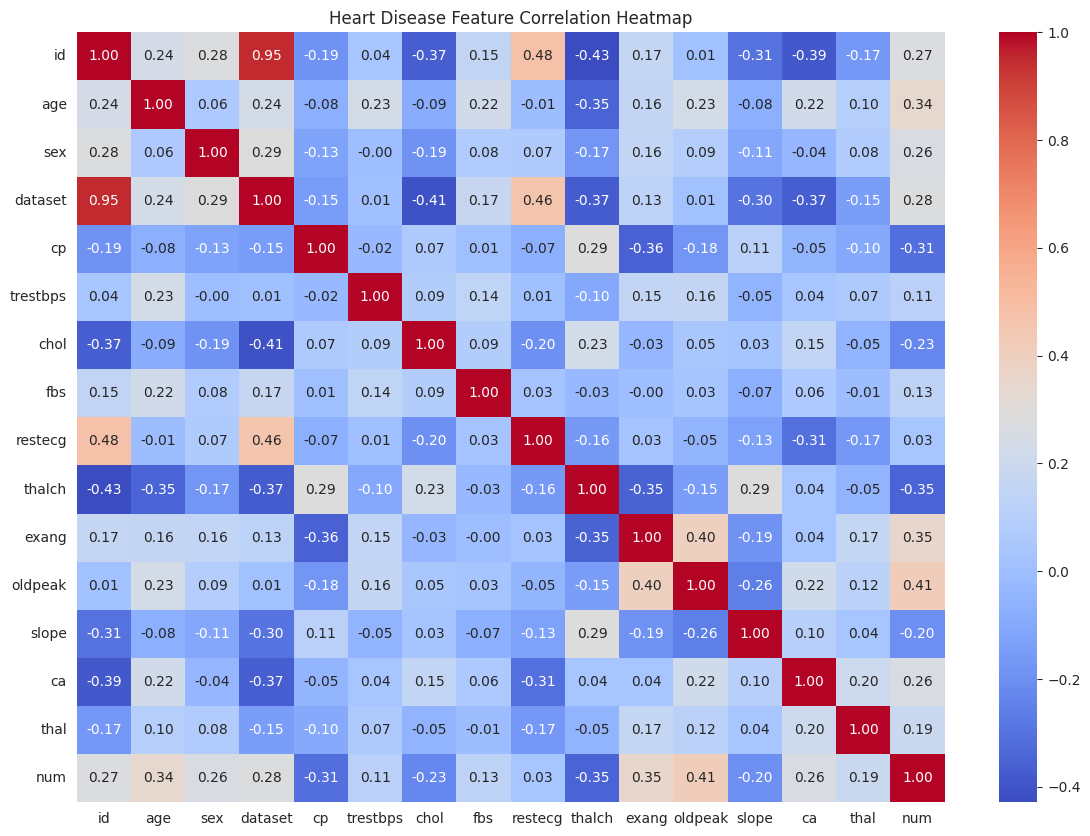

In [7]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heart Disease Feature Correlation Heatmap")

plt.show()

Features and Target Split

In [8]:
TARGET_COLUMN = "num"

X = df.drop([TARGET_COLUMN, "id"], axis=1)
y = df[TARGET_COLUMN]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (920, 14)
Target Shape: (920,)


Filter Method Feature Selection

In [9]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k="all"
)

selector.fit(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print(feature_scores)

     Feature     Score
2    dataset  0.158912
3         cp  0.139713
10   oldpeak  0.123055
9      exang  0.118196
8     thalch  0.104365
5       chol  0.086178
0        age  0.081783
11     slope  0.071079
1        sex  0.046125
13      thal  0.042447
12        ca  0.036963
6        fbs  0.010266
4   trestbps  0.000000
7    restecg  0.000000


Wrapper Method (RFE)

In [10]:
model_rfe = LogisticRegression(max_iter=1000)

rfe = RFE(
    model_rfe,
    n_features_to_select=8
)

rfe.fit(X, y)

rfe_features = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

print(rfe_features.sort_values(by="Ranking"))

     Feature  Selected  Ranking
1        sex      True        1
2    dataset      True        1
3         cp      True        1
7    restecg      True        1
12        ca      True        1
13      thal      True        1
10   oldpeak      True        1
9      exang      True        1
11     slope     False        2
6        fbs     False        3
8     thalch     False        4
0        age     False        5
5       chol     False        6
4   trestbps     False        7


Embedded Method

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X, y)

embedded_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

embedded_importance = embedded_importance.sort_values(
    by="Importance",
    ascending=False
)

print(embedded_importance)

     Feature  Importance
0        age    0.127598
8     thalch    0.126697
5       chol    0.122193
10   oldpeak    0.110541
4   trestbps    0.100719
3         cp    0.084903
2    dataset    0.077183
9      exang    0.054358
13      thal    0.041703
7    restecg    0.039937
12        ca    0.033518
11     slope    0.032016
1        sex    0.025328
6        fbs    0.023307


Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (736, 14)
Test Shape: (184, 14)


Feature Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


Logistic Regression

In [14]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred))

Accuracy: 0.5652173913043478

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.87      0.84        82
           1       0.44      0.57      0.50        53
           2       0.33      0.09      0.14        22
           3       0.04      0.05      0.05        21
           4       0.00      0.00      0.00         6

    accuracy                           0.57       184
   macro avg       0.33      0.31      0.30       184
weighted avg       0.54      0.57      0.54       184



Logistic Regression Confusion Matrix

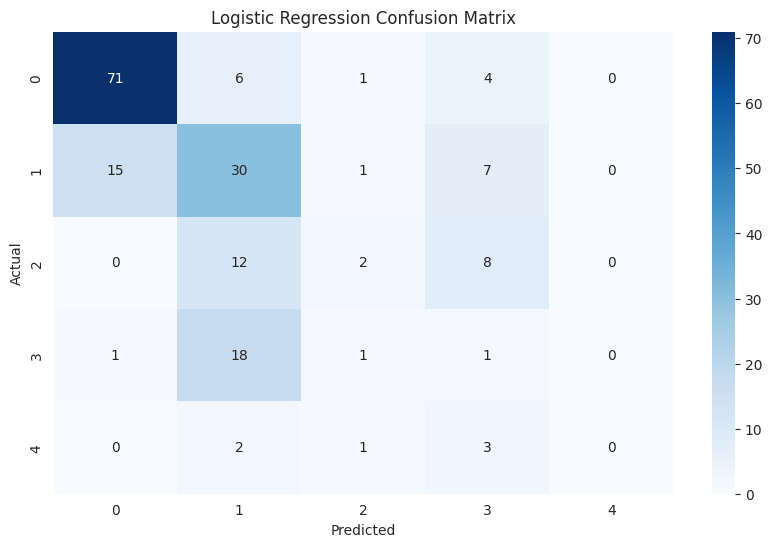

In [15]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Random Forest Model

In [16]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.6195652173913043

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.89      0.83        82
           1       0.59      0.62      0.61        53
           2       0.25      0.18      0.21        22
           3       0.22      0.19      0.21        21
           4       0.00      0.00      0.00         6

    accuracy                           0.62       184
   macro avg       0.37      0.38      0.37       184
weighted avg       0.57      0.62      0.59       184



Random Forest Confusion Matrix

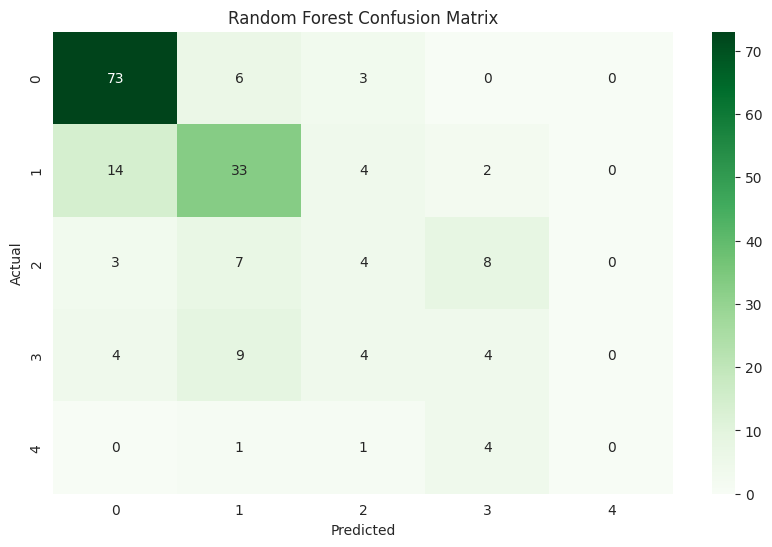

In [17]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

XGBoost Model

In [18]:
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.6086956521739131

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.85      0.80        82
           1       0.61      0.53      0.57        53
           2       0.45      0.45      0.45        22
           3       0.21      0.19      0.20        21
           4       0.00      0.00      0.00         6

    accuracy                           0.61       184
   macro avg       0.41      0.41      0.40       184
weighted avg       0.59      0.61      0.60       184



XGBoost Confusion Matrix

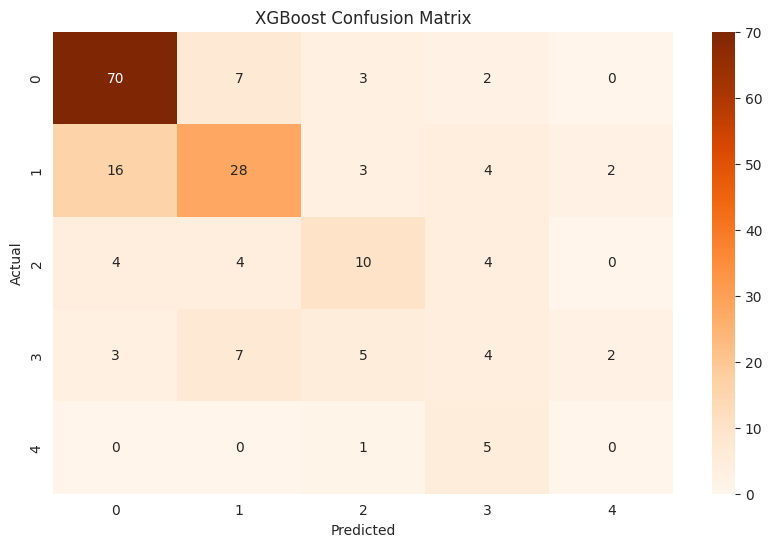

In [19]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Model-Specific Feature Importance

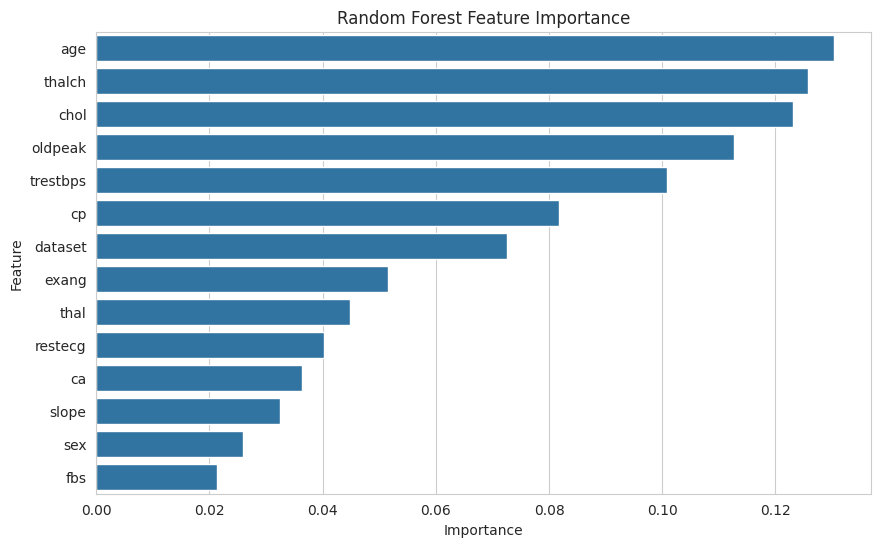

In [20]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")

plt.show()

SHAP Analysis

In [21]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated.")

SHAP values generated.


SHAP Summary Plot

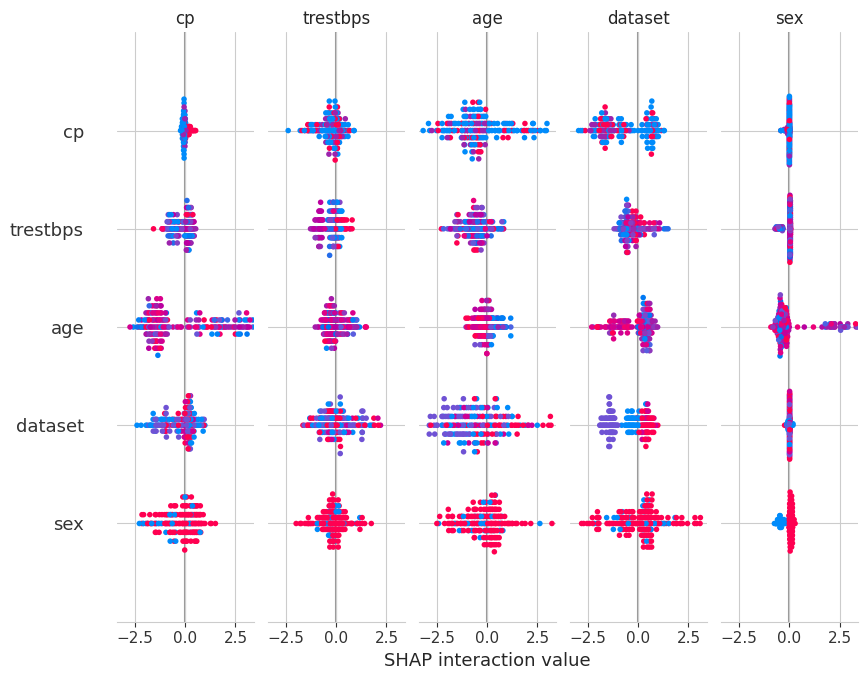

In [22]:
shap.summary_plot(
    shap_values,
    X_test
)

SHAP Bar Plot

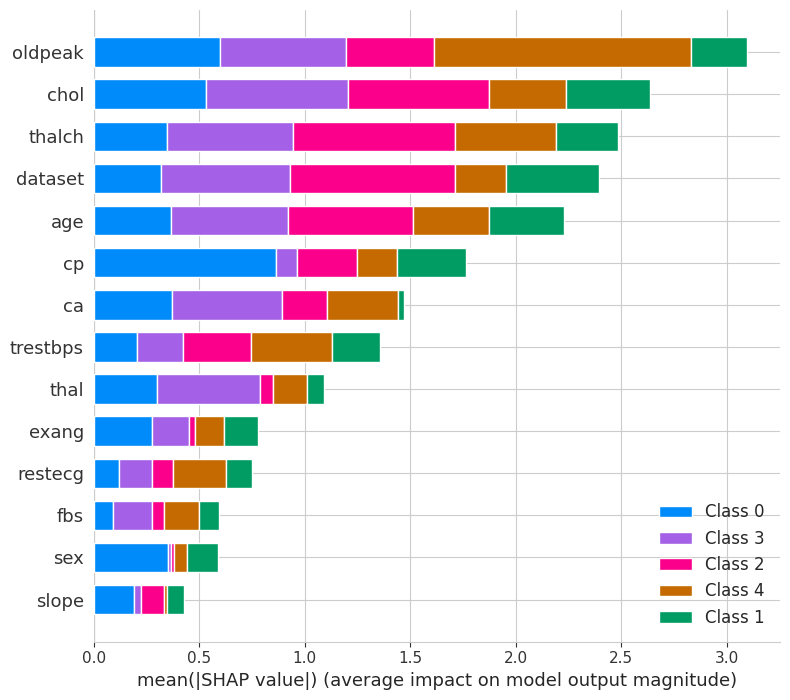

In [23]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

SHAP Dependence Plot

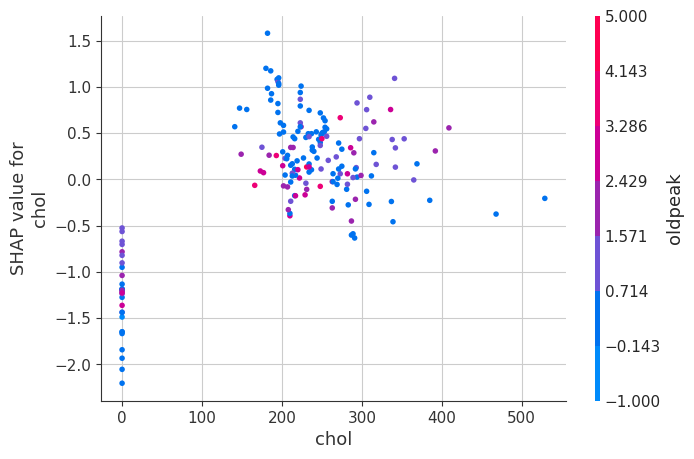

In [24]:
shap.dependence_plot(
    "chol",
    shap_values[:, :, 0], # Select SHAP values for the first class
    X_test
)

SHAP Force Plot

In [25]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0, :, 0],
    X_test.iloc[0]
)

SHAP Waterfall Plot

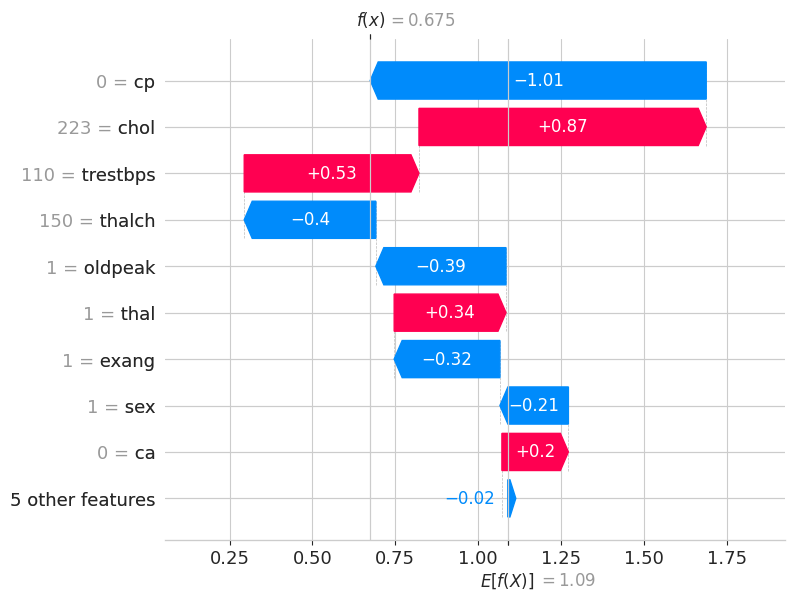

In [26]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 0], # Select SHAP values for the first instance, all features, and the first class
        base_values=explainer.expected_value[0], # Select the base value for the first class
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

Comparative Analysis Table

In [27]:
comparison_df = pd.DataFrame({
    "Filter_Method": feature_scores["Feature"].values[:10],
    "Embedded_Method": embedded_importance["Feature"].values[:10]
})

print(comparison_df)

  Filter_Method Embedded_Method
0       dataset             age
1            cp          thalch
2       oldpeak            chol
3         exang         oldpeak
4        thalch        trestbps
5          chol              cp
6           age         dataset
7         slope           exang
8           sex            thal
9          thal         restecg


Final Interpretation

In [28]:
print("""
INTERPRETATION SUMMARY

1. Multiple feature selection methods consistently
   identified the most influential medical attributes.

2. Tree-based models demonstrated strong capability
   in capturing nonlinear relationships among features.

3. SHAP explanations provided both local and global
   interpretability of heart disease predictions.

4. Features such as cholesterol, chest pain type,
   and maximum heart rate showed significant influence
   on model decisions.

5. Comparative analysis revealed strong consistency
   between embedded feature importance and SHAP-based
   explanations.
""")


INTERPRETATION SUMMARY

1. Multiple feature selection methods consistently
   identified the most influential medical attributes.

2. Tree-based models demonstrated strong capability
   in capturing nonlinear relationships among features.

3. SHAP explanations provided both local and global
   interpretability of heart disease predictions.

4. Features such as cholesterol, chest pain type,
   and maximum heart rate showed significant influence
   on model decisions.

5. Comparative analysis revealed strong consistency
   between embedded feature importance and SHAP-based
   explanations.

